Este notebook foi criado para importar a tabela de Resíduos Sólidos em Excel para o ambiente do Google Colab. Aqui mostraremos a importação da tabela, assim como a criação das tabelas.

In [1]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

In [3]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Origem_Residuo,Umidade_Residuo_pct,Poder_Calorifico_MJkg
0,Comercial,2.0,15.1
1,Comercial,2.0,17.9
2,Comercial,2.0,13.9
3,Comercial,2.0,18.8
4,Comercial,2.0,14.7
...,...,...,...
285,Residencial,77.0,6.5
286,Comercial,77.2,8.1
287,Residencial,77.6,3.6
288,Comercial,78.5,8.8


In [4]:
# Tabela que mostra a quantidade de coletas realizadas em cada regiao
df_Origem_Residuo=df.Origem_Residuo.value_counts()
df_Origem_Residuo

Origem_Residuo
Residencial          143
Comercial             67
Industrial            58
Serviços de Saúde     22
Name: count, dtype: int64

In [5]:
# Impressão do total das coletas realizadas
total_df_Origem_Residuo=df_Origem_Residuo.sum()
total_df_Origem_Residuo

np.int64(290)

In [6]:
# Impressão da tabela com as Regiões de Coleta ordenadas de forma alfabética
dados_v_Origem_Residuo=pd.DataFrame(df_Origem_Residuo)
dados_v_Origem_Residuo

,count
Origem_Residuo,
Residencial,143
Comercial,67
Industrial,58
Serviços de Saúde,22


In [7]:
# Reinicia os índices da região de coleta
dados_v_Origem_Residuo=pd.DataFrame(df_Origem_Residuo).reset_index()
# Renomeia as colunas na tabela com o total de resíduos coletados em cada região da cidade
dados_v_Origem_Residuo.columns=['Origem do Resíduo','Frequência absoluta']
dados_v_Origem_Residuo

print(dados_v_Origem_Residuo)


   Origem do Resíduo  Frequência absoluta
0        Residencial                  143
1          Comercial                   67
2         Industrial                   58
3  Serviços de Saúde                   22


In [8]:
# Cálculo da frequência relativa
dados_v_Origem_Residuo['Frequência relativa(%)']=round((dados_v_Origem_Residuo['Frequência absoluta']/total_df_Origem_Residuo)*100,2)
print(dados_v_Origem_Residuo)

   Origem do Resíduo  Frequência absoluta  Frequência relativa(%)
0        Residencial                  143                   49.31
1          Comercial                   67                   23.10
2         Industrial                   58                   20.00
3  Serviços de Saúde                   22                    7.59


In [9]:
# Criação de uma tabela com os dados de total de resíduos sólidos de cada região e a frequência relativa de porcentagem de cada região
tabela_Dados_v_Origem_Residuo=pd.DataFrame(dados_v_Origem_Residuo)
tabela_Dados_v_Origem_Residuo

,Origem do Resíduo,Frequência absoluta,Frequência relativa(%)
0,Residencial,143,49.31
1,Comercial,67,23.10
2,Industrial,58,20.00
3,Serviços de Saúde,22,7.59


In [10]:
# inserção das frequências acumulativas relativa e absoluta na tabela
tabela_Dados_v_Origem_Residuo['Frequência absoluta acumulada']=tabela_Dados_v_Origem_Residuo['Frequência absoluta'].cumsum()
tabela_Dados_v_Origem_Residuo['Frequência relativa acumulada(%)']=tabela_Dados_v_Origem_Residuo['Frequência relativa(%)'].cumsum()
tabela_Dados_v_Origem_Residuo

,Origem do Resíduo,Frequência absoluta,Frequência relativa(%),Frequência absoluta acumulada,Frequência relativa acumulada(%)
0,Residencial,143,49.31,143,49.31
1,Comercial,67,23.10,210,72.41
2,Industrial,58,20.00,268,92.41
3,Serviços de Saúde,22,7.59,290,100.00


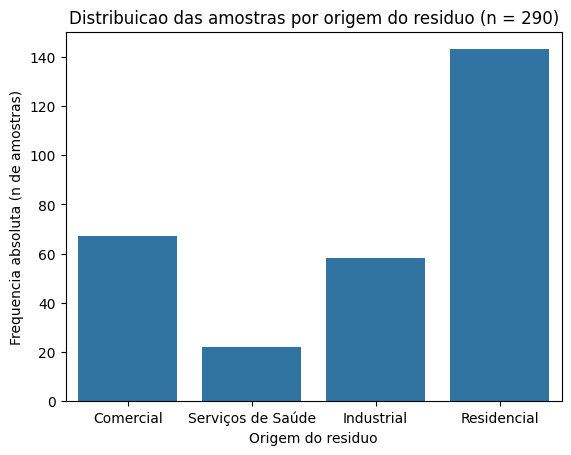

In [11]:
# Grafico de barras preliminar (sem formatacao) - mantido apenas para comparacao
ordem = ['Residencial', 'Comercial', 'Industrial', 'Servicos de Saude']
sns.countplot(x='Origem_Residuo', data=df)
plt.xlabel("Origem do residuo")
plt.ylabel("Frequencia absoluta (n de amostras)")
plt.title("Distribuicao das amostras por origem do residuo (n = 290)")
plt.show()

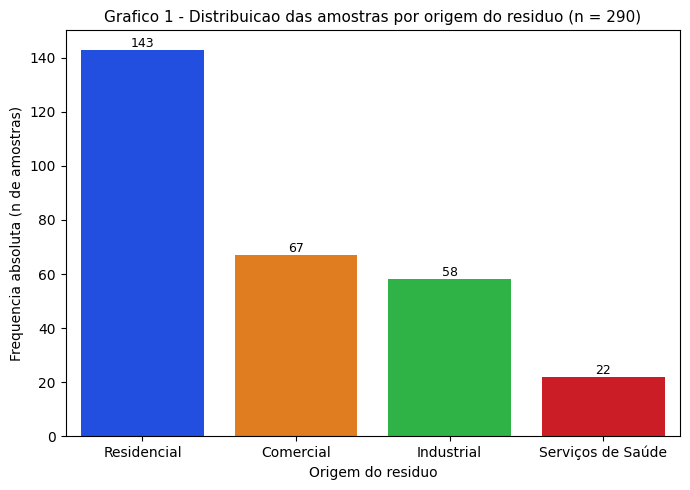

In [12]:
# Grafico de barras final: eixos nomeados, titulo e rotulos de valor
ordem = list(df.Origem_Residuo.value_counts().index)
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x='Origem_Residuo', data=df, order=ordem, hue='Origem_Residuo',
              hue_order=ordem, palette='bright', legend=False, ax=ax)
ax.set_xlabel("Origem do residuo", size=10)
ax.set_ylabel("Frequencia absoluta (n de amostras)", size=10)
ax.set_title("Grafico 1 - Distribuicao das amostras por origem do residuo (n = 290)", size=11)
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
plt.tight_layout()
plt.show()

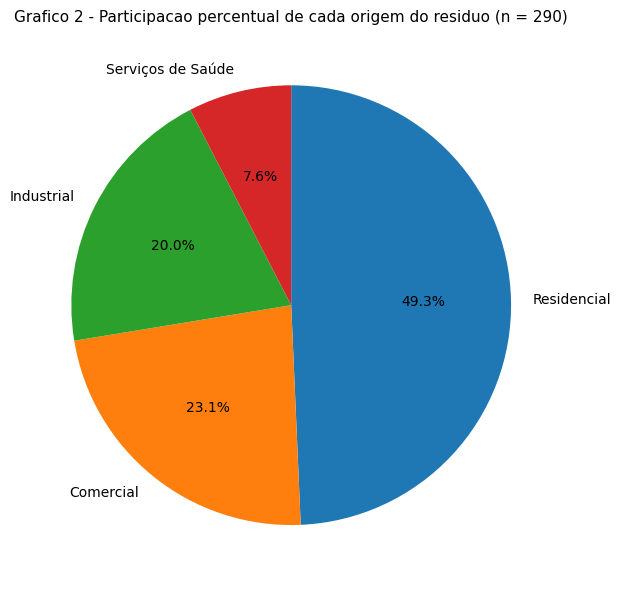

In [13]:
# Grafico de setores: valores lidos diretamente da tabela (evita numeros digitados a mao)
rotulos = list(tabela_Dados_v_Origem_Residuo['Origem do Resíduo'])
valores = list(tabela_Dados_v_Origem_Residuo['Frequência absoluta'])

plt.figure(figsize=(7, 6))
plt.pie(valores, labels=rotulos, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Grafico 2 - Participacao percentual de cada origem do residuo (n = 290)", size=11)
plt.tight_layout()
plt.show()

Existem 143 registros de resíduos sólidos de origem residencial na base de dados. Sendo assim, a origem de resíduo Residencial é a informação da variável de "Origem de Resíduo" que mais se repete ao longo da base de dados.

In [14]:
df.Origem_Residuo.mode()

0    Residencial
Name: Origem_Residuo, dtype: str

**Medida resumo (moda):** a moda da variavel qualitativa nominal Origem do Residuo e a categoria **Residencial**, observada em **143 das 290 amostras (49,31%)**. Como a variavel e nominal, a moda nao possui unidade metrica: ela e expressa na propria categoria, sendo a unidade subjacente da contagem o numero de amostras. Media e mediana nao sao definidas para variaveis nominais.

In [15]:
tabela_Dados_v_Origem_Residuo.to_excel("Tabela_Variaveis_Escolhidas.xlsx",sheet_name="Dados",index=False)